# Q28 — ARA^9 Interlocking Rotational Transport

## TL;DR

The checksum-frozen result is **INCONCLUSIVE**, not a confirmation of an
angled rotational pivot.

What survived on the hidden time half:

- the full oriented relation fitted its later neighbour web much better after
  an allowed 0°/180° reorientation than with positive scaling alone:
  residual `0.1016` versus `0.5462`, an `81.39%` reduction;
- the exact trajectory beat displaced-seed and displaced-time controls in all
  2,000 paired trial bootstraps;
- development selected lag 2, and the hidden half independently reached its
  minimum at lag 2;
- singular-value shape retention was `0.9918`.

Why the claim is not supported:

- only 76,393 hidden events survived, below the frozen 100,000-event gate;
- every source relation is exactly diagonal and symmetric in this simulator;
- endpoint reversal therefore changes nothing, so the mandatory
  shared-endpoint control fails exactly;
- fitted angles are only 0° or 180°, not a continuous angled rotational point.

## Context & Methods

Q27 found a weaker ordered release-to-neighbour accumulation relation but no
stable determinant-orientation flip. Q28 tested the user's ARA hypothesis that
the larger pattern may instead be an interlocking web travelling around a
rotational point.

For each two-qubit pair, Q28 retains the complete connected 3×3 relation
`C = T - a bᵀ`. A source release at time `t` is compared with the
accumulation-weighted web of active pairs sharing one endpoint at time
`t + lag`. The only fitted transformation is one proper SO(3) rotation plus a
positive scale. Development times 0–241 selected one lag from 1–8; hidden
times 250–491 evaluated that frozen lag.

Controls use no rotation, the opposite endpoint, a seed displacement, a time
displacement, and zero lag. This source was already opened by Q27, so Q28 is
registered but not blind.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import csv
import json

HERE = Path.cwd()
if not (HERE / "Q28_ARA9_INTERLOCKING_ROTATIONAL_TRANSPORT_RESULTS.json").exists():
    HERE = Path(r"F:/SystemFormulaFolder/GIT/ARA-GIT/analysis/quantum")

results = json.loads(
    (HERE / "Q28_ARA9_INTERLOCKING_ROTATIONAL_TRANSPORT_RESULTS.json").read_text(
        encoding="utf-8"
    )
)
validation = json.loads(
    (HERE / "Q28_ARA9_INTERLOCKING_ROTATIONAL_TRANSPORT_VALIDATION.json").read_text(
        encoding="utf-8"
    )
)
assert validation["status"] == "PASS"
assert validation["checks_passed"] == validation["checks_total"] == 38
assert results["verdict"] == "INCONCLUSIVE"
print("Independent validation:", validation["status"], "38/38")
print("Frozen verdict:", results["verdict"])
print("Development-selected lag:", results["selected_lag"])

Independent validation: PASS 38/38
Frozen verdict: INCONCLUSIVE
Development-selected lag: 2


## Data

In [2]:
print("DOI:", results["source"]["doi"])
print("HDF5 SHA-256:", results["source"]["hdf5_sha256"])
print("Protocol SHA-256:", results["source"]["protocol_sha256"])
print("Evidence tier:", results["source"]["evidence_tier"])
print("Connected matrices:", 2 * 100 * 500 * 66)
print("Hidden eligible events:", results["hidden"]["pooled"]["events"])
for key, value in results["source_quality"].items():
    print(f"{key}: {value}")

DOI: 10.5281/zenodo.16753415
HDF5 SHA-256: 0e10afb6e5c7bcc3b469a9bb18a9bcae9469bfae165d5da5add93eeeb1972eeb
Protocol SHA-256: 400789b6ccfa22962d6860b23c379fada7ca00684346bab19daa8fbd88481d14
Evidence tier: registered on fully opened source; not blind
Connected matrices: 6600000
Hidden eligible events: 76393
maximum_trace_error: 2.534210216253996e-05
maximum_hermiticity_error: 0.0
minimum_eigenvalue: -3.115426222572576e-07


## Results

In [3]:
h = results["hidden"]["pooled"]
summary = {
    "rotation residual": h["rotation_error"],
    "no-rotation residual": h["no_rotation_error"],
    "rotation gain": h["rotation_gain"],
    "wrong-endpoint residual": h["wrong_endpoint_error"],
    "seed-displaced residual": h["seed_error"],
    "time-displaced residual": h["time_error"],
    "zero-lag residual": h["lag_zero_error"],
    "shape similarity": h["spectrum_similarity"],
}
for label, value in summary.items():
    print(f"{label:28s} {value:.6f}")

rotation residual            0.101637
no-rotation residual         0.546173
rotation gain                0.813911
wrong-endpoint residual      0.101637
seed-displaced residual      0.153025
time-displaced residual      0.152886
zero-lag residual            0.132915
shape similarity             0.991784


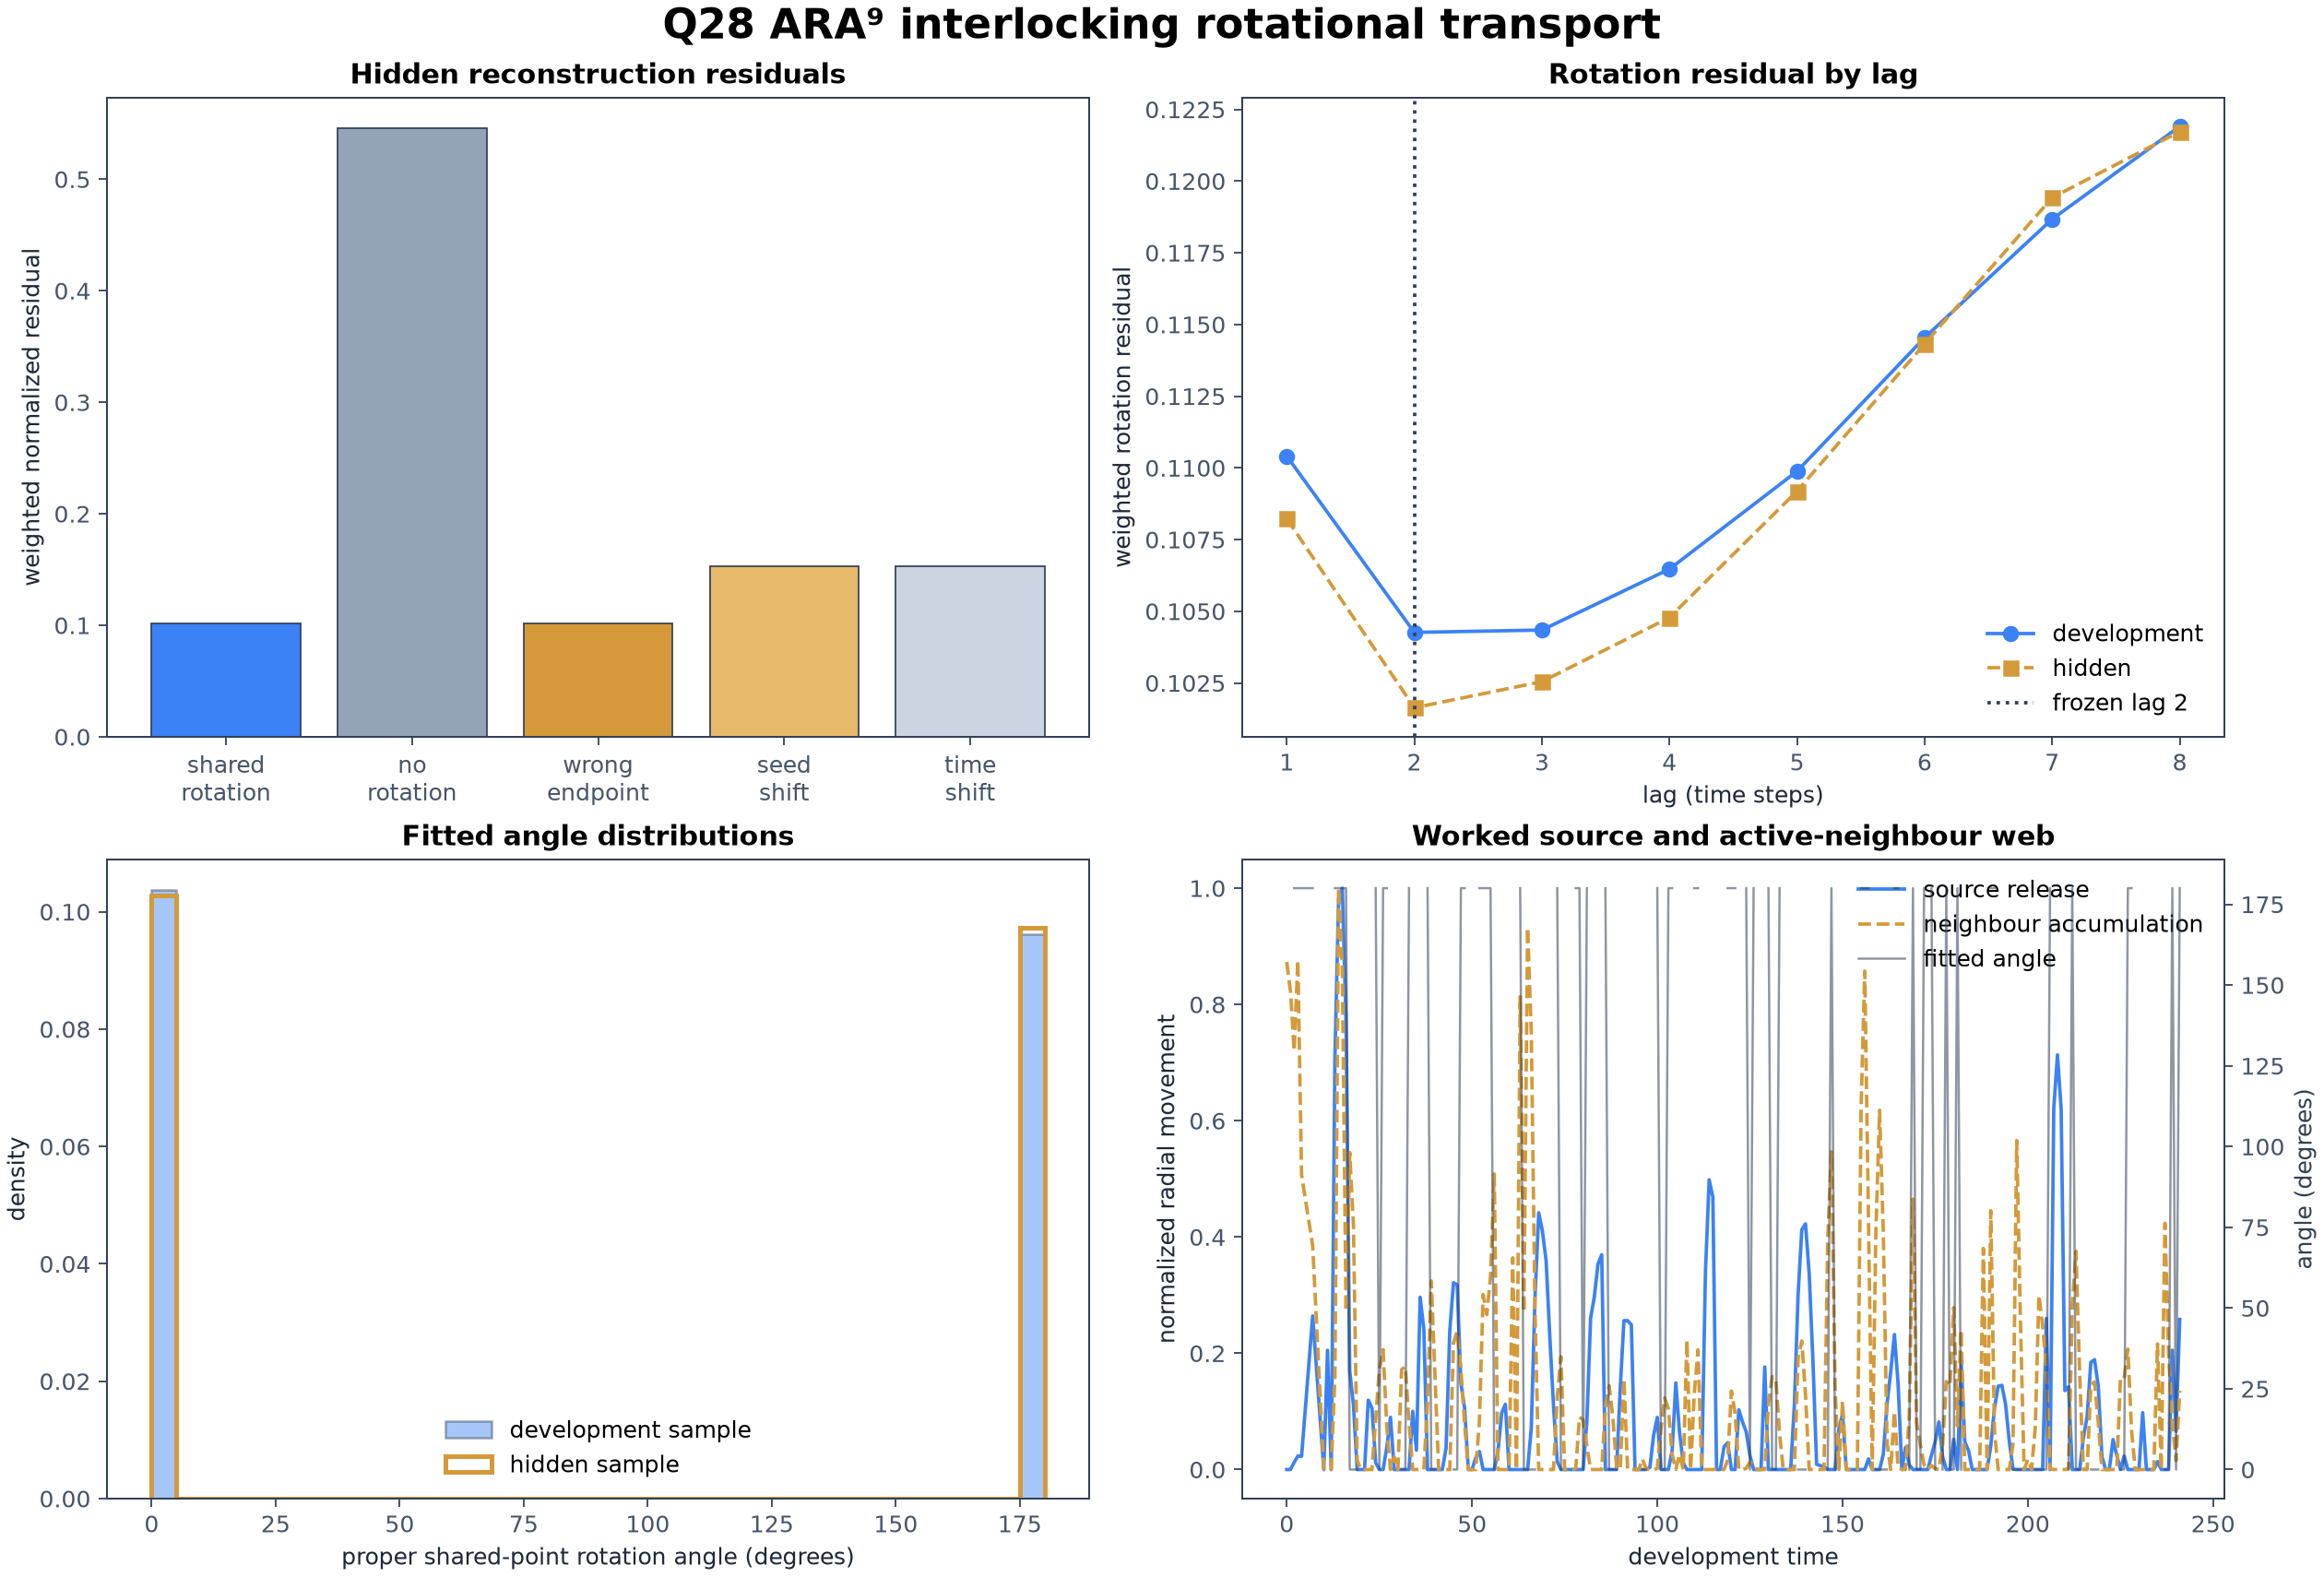

In [4]:
display(
    Image(
        filename=str(
            HERE / "Q28_ARA9_INTERLOCKING_ROTATIONAL_TRANSPORT_GEOMETRY.png"
        )
    )
)

### What the figure says

The top-left panel shows a strong relation that is lost if the sign-oriented
state is flattened into positive scaling only. Exact time and seed identity
matter. But the correct- and wrong-endpoint bars coincide because the complete
source matrices are diagonal and symmetric.

The top-right panel is the cleanest travelling result: development selects lag
2 and the independently evaluated hidden half has the same minimum. The
bottom-left panel shows why this is not evidence for an oblique pivot: the
allowed rotations collapse to 0° and 180°. The worked trajectory shows
release and neighbour accumulation recurring through time, with the fitted
binary orientation overlaid.

In [5]:
for gate, passed in results["gates"].items():
    print(f"{gate:48s} {'PASS' if passed else 'FAIL'}")

D1_source_checksums                              PASS
D2_complete_branches_trials_pairs                PASS
D3_known_source_precision                        PASS
E1_eligibility                                   FAIL
I1_rotation_gain_10pct                           PASS
I2_bootstrap_rotation_beats_no_rotation          PASS
I3_shared_endpoint_5pct_and_bootstrap            FAIL
I4_displaced_controls                            PASS
I5_shape_similarity                              PASS
T1_positive_lag_5pct_and_bootstrap               PASS
T2_angle_within_15deg                            PASS
T3_half_weight_inside_development_iqr            PASS
T4_same_direction_both_strata                    FAIL


## ARA and established-physics readings

| ARA reading | Established quantum/data reading |
|---|---|
| The larger web retains a recurring phase/flip relation that a scalar closure cut discarded. | Keeping the full connected-correlation block retains sign structure lost by `abs(det C)`. |
| Release is followed most cleanly by neighbour-web accumulation two slices later. | A development-selected lag-2 association replicates on the hidden half and beats zero lag. |
| The observed movement is a 0↔2-style singularity flip, not yet the proposed angled interlock. | This simulator's connected blocks are diagonal; proper fits therefore reduce to 0°/180° sign reorientations. |
| Interlocking through a named shared endpoint remains unresolved. | Matrix transpose is identical here, making the correct- versus wrong-endpoint test non-identifiable. |

The geometry verdict is therefore narrower than the frozen claim: **binary
phase-flip transport survives; continuous angled interlocking is not tested by
this source**.

## Evidence boundary and next test

This is complete public simulated data and an independently validated frozen
analysis, but the source had already been opened by Q27. It does not establish
hardware behaviour, a new quantum law, or universal fractality.

The next decisive dataset must expose non-zero off-diagonal connected
correlations in a fixed shared coordinate frame. Only then can endpoint
reversal differ from the intended shared endpoint, and only then can a
continuous rotation angle be measured rather than forced into 0°/180°.

## Reproduction

From `analysis/quantum`, using the bundled Python environment with
`.q27_deps` on `PYTHONPATH`:

```powershell
python q28_ara9_interlocking_rotational_transport_test.py extract --workers 6
python q28_ara9_interlocking_rotational_transport_test.py analyse
python q28_ara9_interlocking_rotational_transport_validate.py
python q28_build_notebook.py
```

The 237.6 MB derived matrix cache is excluded from Git and recreated from the
checksum-locked Q27 public source.